In [125]:
from SparseDPC.vectorized.utils import DoubleIntegrator2D, CustomLogger, solve_and_plot_ipopt
from SparseDPC.vectorized.sindy import CompiledFunctionLibrary, SINDyVectorized
from SparseDPC.vectorized.trainer import SparseTrainer, SparsePolicyBuilder2D
from SparseDPC.vectorized.data import get_policy_data
from SparseDPC.vectorized.plot import *
import copy
from SparseDPC.vectorized.utils import DoubleIntegrator2DParam
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import integrators

# Set random seed for reproducibility
torch.manual_seed(0)

device = torch.device("cpu")


In [126]:
import torch
import torch.nn as nn

import torch

run_id = 1
models_dir = f"../results/tests/dynamics/run_{run_id}/saved_models"   # change root here
ckpt = torch.load(str(models_dir) + "/sindy.pt", map_location=device)

# Rebuild library and model skeleton
lib = CompiledFunctionLibrary(**ckpt["lib_cfg"])
sindy = SINDyVectorized(
    library=lib,
    n_out=ckpt["model_cfg"]["n_out"],
    device=device,
)

# Install pruning structure BEFORE loading weights (so shapes match)
sindy.active_idx = [list(map(int, s)) for s in ckpt["active_idx"]]

# Resize Xi ParameterList to match saved shapes
for i, idxs in enumerate(sindy.active_idx):
    sindy.Xi[i] = nn.Parameter(torch.zeros(len(idxs), 1, device=device), requires_grad=True)

# Recompile the fast plan for the current union of terms
sindy._plan = sindy._recompile_fast_path(device=device)

# Load weights
sindy.load_state_dict(ckpt["state_dict"], strict=True)


<All keys matched successfully>

In [127]:
import torch
import torch.nn as nn


import torch

run_id = 2
models_dir = f"../results/tests/sparse/run_{run_id}/SINDy/saved_models"   # change root here
ckpt = torch.load(str(models_dir) + "/policy_sparse.pt", map_location=device)

# Rebuild library and model skeleton
policy_lib = CompiledFunctionLibrary(**ckpt["lib_cfg"])
policy_sparse = SINDyVectorized(
    library=policy_lib,
    n_out=ckpt["model_cfg"]["n_out"],
    policy_name=ckpt["model_cfg"]["policy_name"],
    device=device,
)

# Install pruning structure BEFORE loading weights (so shapes match)
policy_sparse.active_idx = [list(map(int, s)) for s in ckpt["active_idx"]]

# Resize Xi ParameterList to match saved shapes
for i, idxs in enumerate(policy_sparse.active_idx):
    policy_sparse.Xi[i] = nn.Parameter(torch.zeros(len(idxs), 1, device=device), requires_grad=True)

# Recompile the fast plan for the current union of terms
policy_sparse._plan = policy_sparse._recompile_fast_path(device=device)

# Load weights
policy_sparse.load_state_dict(ckpt["state_dict"], strict=True)


<All keys matched successfully>

In [128]:
policy_sparse.pretty_print()

u0 = -5.4323e-01·x0 + +1.8101e-01·r1 + +3.5956e-01·sqrt(x0) + -2.2505e-01·sqrt(x3) + -6.6320e-01·x0*r1 + -1.4094e+00·x1*r1 + +1.3210e+00·x2*r0 + +1.1133e+00·x3*r0
u1 = +1.5959e-01·x1 + -6.5742e-01·x2 + -1.0599e+00·x3 + +6.5525e-01·r1 + +1.7086e-01·sqrt(x0)


In [129]:
sindy.pretty_print()

dx0/dt = +1.0000e+00·x1
dx1/dt = -1.9802e-01·x1 + +9.9004e-01·u0
dx2/dt = +1.0000e+00·x3
dx3/dt = -1.9800e-01·x3 + +9.9007e-01·u1


#### Create a nominal and noisy system

In [130]:
noisy_policy_sparse = copy.deepcopy(policy_sparse)

ellipse_configs = {"p": 1.5,
                   "b": 13,
                   "c": 0.0,
                   "d": 0.0,
                   "theta": 0.0}

nsteps = 300
xmin = -1.
xmax = 1.
umin = -2.
umax = 2.

# Ground truth system model
gt_model = DoubleIntegrator2D()
# Sampling rate
ts = gt_model.params[1]["ts"]

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = 2


def make_square(center, length):
    """
    Build a rectangle ((x1,y1),(x2,y2)) from center and side length.
    center: (cx, cy)
    length: full side length
    """
    cx, cy = center
    half = length / 2.0
    return ((cx - half, cy - half), (cx + half, cy + half))

side = 0.5   # for example, 0.5 x 0.5 squares

# initial region center
init_center = (0.6, -0.6)
init_rect = make_square(init_center, side)

# reference region center)
ref_center = (-0.6, 0.6)
ref_rect = make_square(ref_center, side)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


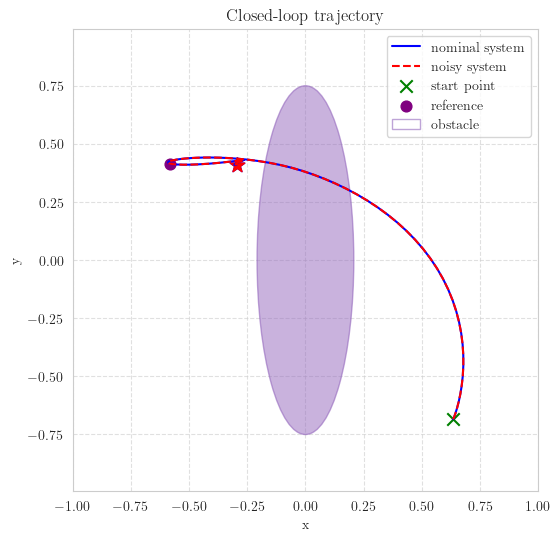

In [131]:
# Closed-loop simulation setup


data = make_test_sample(
    nx=nx, nsteps=nsteps, seed= 87
    , device=device,
    ellipse= ellipse_configs,
    init_vel_std=0.0,
    init_rect= init_rect,
    ref_rect= ref_rect,
)

double_integrator = DoubleIntegrator2DParam()
double_integrator.mx = torch.nn.Parameter(torch.tensor(gt_model.mx), requires_grad=False)
double_integrator.my = torch.nn.Parameter(torch.tensor(gt_model.my), requires_grad=False)
double_integrator.cx = torch.nn.Parameter(torch.tensor(gt_model.cx), requires_grad=False)
double_integrator.cy = torch.nn.Parameter(torch.tensor(gt_model.cy), requires_grad=False)
double_integrator.kx = torch.nn.Parameter(torch.tensor(gt_model.kx), requires_grad=False)
double_integrator.ky = torch.nn.Parameter(torch.tensor(gt_model.ky), requires_grad=False)


gt_integrator = integrators.Euler(double_integrator, h=torch.tensor(ts))
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

policy_node = Node(
            lambda xn,r : torch.clamp(policy_sparse(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )

noisy_policy_node = Node(
            lambda xn,r : torch.clamp(noisy_policy_sparse(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="noisy_policy_combined"
        )
# Compose symbolic closed-loop system: policy + true plant
gt_sindy_policy_system = copy.deepcopy(System([policy_node, gt_integrator_node]))
gt_sindy_policy_system_noisy = copy.deepcopy(System([noisy_policy_node, gt_integrator_node]))

# Simulate system
gt_sindy_policy_system.nsteps = nsteps
gt_sindy_policy_system_noisy.nsteps = nsteps

trajectories = gt_sindy_policy_system(data)
trajectories_noisy = gt_sindy_policy_system_noisy(data)

traj_x = trajectories["xn"]
traj_r = trajectories['r']

traj_x_noisy = trajectories_noisy["xn"]
traj_r_noisy = trajectories_noisy['r']

# suppose you produced a rollout: traj_x: (B, T, nx), traj_r: (B, T, 2)
fig, ax = plot_trajectories_with_ellipse(
    traj_list=[
        {"traj": traj_x, "label": "nominal system", "color": "blue"},
        {"traj": traj_x_noisy,   "label": "noisy system",   "color": "red", "linestyle": "--"}
    ],
    r = traj_r,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    batch_idx=0, xmin=xmin, xmax=xmax,
    title="Closed-loop trajectory"
)


#### Make functions to compute the gradients for policy

In [132]:
import torch

def compute_updates(dyn_model, policy_sparse, x, ref, u, *, use_coupling=True):
    params = tuple(policy_sparse.Xi)
    for p in policy_sparse.Xi:
        assert p.requires_grad

    F_vec = dyn_model(x, u).squeeze(0)       # (nx,)
    nx = F_vec.numel()
    e = (ref - x).mean(0)                    # (nx,)

    # rows of ∂F_i/∂a_k
    g_rows = []
    for i in range(nx):
        gi = torch.autograd.grad(F_vec[i], params, retain_graph=True, create_graph=False, allow_unused=False)
        g_rows.append(gi)

    if use_coupling and nx >= 4:
        x_req = x.detach().requires_grad_(True)

        def F_x_fixed(x_var):
            # keep batch dimension to keep jacobian shapes saner
            return dyn_model(x_var, u)       # (1, nx)

        J_x = torch.autograd.functional.jacobian(F_x_fixed, x_req, vectorize=True)
        # Normalize to (nx, nx) robustly
        J_x = J_x.squeeze()                  # drop singleton dims
        if J_x.dim() != 2:
            J_x = J_x.reshape(nx, nx)

        # Apply your coupling: 0←1 and 2←3
        alpha01 = J_x[0, 1]
        g_rows[0] = tuple(g * alpha01 for g in g_rows[1])
        alpha23 = J_x[2, 3]
        g_rows[2] = tuple(g * alpha23 for g in g_rows[3])

    # denom = 1 + ||J_a||_F^2
    fro2 = F_vec.new_zeros(())
    for i in range(nx):
        for g in g_rows[i]:
            fro2 = fro2 + (g**2).sum()
    denom = 1.0 + fro2

    # updates_k = (Σ_i e_i * ∂F_i/∂a_k) / denom
    updates = []
    for k, _p in enumerate(policy_sparse.Xi):
        num_k = sum(e[i] * g_rows[i][k] for i in range(nx))
        updates.append(num_k / denom)

    return updates


import torch

def apply_policy_updates(policy_sparse, updates, gamma=1.0, clip=None):
    """
    Add updates to policy_sparse.Xi parameters:
      Xi_k <- Xi_k + gamma * updates[k]

    Args:
        policy_sparse: object with attribute `Xi` (e.g., nn.ParameterList of coef tensors)
        updates: list[Tensor], same structure/shapes as policy_sparse.Xi
        gamma: scalar step size
        clip: optional float for elementwise clipping of the update
    """
    assert len(updates) == len(policy_sparse.Xi), "updates and Xi must align"

    with torch.no_grad():
        for Xi_k, dk in zip(policy_sparse.Xi, updates):
            # ensure dtype/device match
            dk = dk.to(dtype=Xi_k.dtype, device=Xi_k.device)
            # guard against NaN/Inf
            dk = torch.nan_to_num(dk, nan=0.0, posinf=0.0, neginf=0.0)
            # optional clipping
            if clip is not None:
                dk = dk.clamp(min=-clip, max=clip)
            # in-place coefficient update
            Xi_k.add_(gamma * dk)


In [133]:
pol_configs = {
    "l1_coef": 0.0002,
    "Q_con_obs": 200.0,
    "Q_con_x": 10.0,
    "Q_con_u": 10.0,
    "Q_u": 0.02,
    "Q_r": 1.0,
    "Q_dx": 0.0,
    "Q_du": 0.0001,
    "lr": 0.002,
    "epochs": 10000,
    "threshold": 0.08,
    "prune_every": 2000,
    "prune_every_min": 300,
    "prune_every_decay": 200,
    "change_prune_every": True,
    "threshold_mult": 1.3,
    "threshold_max" : 0.12,
    "prune_noise": 0.01,
    "lr_decay_gamma": 0.95,
    "lr_decay_step": 50,
    "l1_decay": 0.9,
}

x  = variable('xn')
x1 = x[:, :, [0]]
x2 = x[:, :, [2]]

p = ellipse_configs["p"]
b = ellipse_configs["b"]
c = ellipse_configs["c"]
d = ellipse_configs["d"]

obstacle_pen = pol_configs["Q_con_obs"] * (((p/2)**2 < (b*(x1 - c)**2 + (x2 - d)**2)) ^ 2)
obstacle_pen.update_name("obstacle_pen")

In [134]:
# # Build lists for dynamics and policies (extend these if you have >2)
# x_trajectory = data['xn'].detach()[:, 0, :].unsqueeze(1)
# u_trajectory = torch.zeros([1,1,2])
# gamma = 1.
# error_hist = []
# f_hist = []
#
# # --- Define the obstacle_pen variable expression (keeps graph) ---
#
#
# # --- Roll out system for several steps ---
# N = 5
# gt_sindy_policy_system_noisy.nsteps = T
# sys_out = gt_sindy_policy_system_noisy({
#     'xn': x_trajectory[:, -1, :].unsqueeze(0),
#     'r' : data['r'][:, len(x_trajectory[0]):len(x_trajectory[0])+T, :]  # (B,T,2)
# })
#
# # --- Evaluate obstacle_pen on the rollout (returns dict, still connected to graph) ---
# out = obstacle_pen(sys_out)
#
# # out has three keys: "obstacle_pen", "obstacle_pen_value", "obstacle_pen_violation"
# # each is a torch.Tensor with grad history, shape (B,T,...)
# weighted = out["obstacle_pen"]            # weighted penalty (with pol_configs["Q_con_obs"])
# raw_val  = out["obstacle_pen_value"]      # raw inequality residual
# violate  = out["obstacle_pen_violation"]  # hinge-squared violation
#
# print(weighted.shape, raw_val.shape, violate.shape)
# # These tensors still require_grad and can be used in loss.backward()
#


In [135]:
# Build lists for dynamics and policies (extend these if you have >2)
noisy_policy_sparse = copy.deepcopy(policy_sparse)
noisy_policy_node = Node(
            lambda xn,r : torch.clamp(noisy_policy_sparse(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="noisy_policy_combined"
        )
gt_sindy_policy_system_noisy = copy.deepcopy(System([noisy_policy_node, gt_integrator_node]))

x_trajectory_unconst = data['xn'].detach()[:, 0, :].unsqueeze(1)
u_trajectory_unconst = torch.zeros([1,1,2])
gamma = 0.2
error_hist = []
f_hist = []

for t in range(1, len(data['r'][0])):

    gt_sindy_policy_system_noisy.nsteps = 1
    next_step_data = gt_sindy_policy_system_noisy({
        'xn': x_trajectory_unconst[:, -1, :].unsqueeze(0),
        'r' : data['r'][:, len(x_trajectory_unconst[0]), :].unsqueeze(0)
    })

    x = next_step_data['xn'][:, -1, :].detach()
    r = next_step_data['r'][:,  -1, :].detach()
    u = noisy_policy_sparse(x,r)

    out = torch.zeros((1, r.numel() * 2), dtype=r.dtype)
    out[0, ::2] = r
    r = out

    # Compute grads for the reference tracking only
    policy_grads = compute_updates(
        dyn_model=sindy,
        policy_sparse=noisy_policy_sparse,
        x=x, ref=r,
        u=u
    )

    # # Apply the updates
    apply_policy_updates(noisy_policy_sparse, policy_grads, gamma=gamma, clip=1.0)
    print(f"Timestep: {t}, ref_grads: {policy_grads}")
    # Log trajectories
    x_trajectory_unconst = torch.cat([x_trajectory_unconst, next_step_data['xn'].detach()[:, -1:, :]], dim=1)
    u_trajectory_unconst = torch.cat([u_trajectory_unconst, next_step_data['u'].detach()[:,  -1:, :]], dim=1)


Timestep: 1, ref_grads: [tensor([[-0.1213],
        [-0.0787],
        [-0.1522],
        [-0.0559],
        [-0.0500],
        [-0.0029],
        [-0.0760],
        [ 0.0095]]), tensor([[ 0.0057],
        [-0.1053],
        [ 0.0132],
        [ 0.0635],
        [ 0.1227]])]
Timestep: 2, ref_grads: [tensor([[-0.1201],
        [-0.0775],
        [-0.1502],
        [-0.0763],
        [-0.0495],
        [-0.0041],
        [-0.0739],
        [ 0.0180]]), tensor([[ 0.0072],
        [-0.0921],
        [ 0.0225],
        [ 0.0562],
        [ 0.1089]])]
Timestep: 3, ref_grads: [tensor([[-0.1181],
        [-0.0756],
        [-0.1471],
        [-0.0894],
        [-0.0487],
        [-0.0040],
        [-0.0703],
        [ 0.0253]]), tensor([[ 0.0063],
        [-0.0788],
        [ 0.0284],
        [ 0.0493],
        [ 0.0960]])]
Timestep: 4, ref_grads: [tensor([[-0.1153],
        [-0.0732],
        [-0.1430],
        [-0.0977],
        [-0.0476],
        [-0.0028],
        [-0.0656],
        [ 0.03

In [136]:
# Build lists for dynamics and policies (extend these if you have >2)
noisy_policy_sparse = copy.deepcopy(policy_sparse)
noisy_policy_node = Node(
            lambda xn,r : torch.clamp(noisy_policy_sparse(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="noisy_policy_combined"
        )
gt_sindy_policy_system_noisy = copy.deepcopy(System([noisy_policy_node, gt_integrator_node]))

x_trajectory_const = data['xn'].detach()[:, 0, :].unsqueeze(1)
u_trajectory_const = torch.zeros([1,1,2])
gamma = 0.1
error_hist = []
f_hist = []
N = 8
for t in range(1, len(data['r'][0])):

    gt_sindy_policy_system_noisy.nsteps = 1
    next_step_data = gt_sindy_policy_system_noisy({
        'xn': x_trajectory_const[:, -1, :].unsqueeze(0),
        'r' : data['r'][:, len(x_trajectory_const[0]), :].unsqueeze(0)
    })

    x = next_step_data['xn'][:, -1, :].detach()
    r = next_step_data['r'][:,  -1, :].detach()
    u = noisy_policy_sparse(x,r)

    # Compute grads for the obstacle avoidance:

    gt_sindy_policy_system_noisy.nsteps = N
    sys_out = gt_sindy_policy_system_noisy({
        'xn': x_trajectory_const[:, -1, :].unsqueeze(0),
        'r' : r.unsqueeze(0).expand(1, N, -1)  # (B,T,2)
    })

    # --- Evaluate obstacle_pen on the rollout (returns dict, still connected to graph) ---
    out = obstacle_pen(sys_out)
    weighted = out["obstacle_pen"]
    for pol in noisy_policy_sparse.Xi:
        if pol.grad is not None:
            pol.grad.zero_()
    weighted.backward()
    policy_grads_obs = []
    for pol in noisy_policy_sparse.Xi:
        policy_grads_obs.append(-1. * pol.grad)


    out = torch.zeros((1, r.numel() * 2), dtype=r.dtype)
    out[0, ::2] = r
    r = out

    # Compute grads for the reference tracking only
    policy_grads_ref = compute_updates(
        dyn_model=sindy,
        policy_sparse=noisy_policy_sparse,
        x=x, ref=r,
        u=u
    )

    print(f"Timestep: {t}, obstacle grads: {policy_grads_obs}, ref_grads: {policy_grads_ref}, weighted: {weighted}")
    policy_grads = [a + b for a, b in zip(policy_grads_obs, policy_grads_ref)]

    # # Apply the updates
    apply_policy_updates(noisy_policy_sparse, policy_grads, gamma=0.3 if weighted==0 else gamma, clip=1.0)

    # Log trajectories
    x_trajectory_const = torch.cat([x_trajectory_const, next_step_data['xn'].detach()[:, -1:, :]], dim=1)
    u_trajectory_const = torch.cat([u_trajectory_const, next_step_data['u'].detach()[:,  -1:, :]], dim=1)


Timestep: 1, obstacle grads: [tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.]]), tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.]])], ref_grads: [tensor([[-0.1213],
        [-0.0787],
        [-0.1522],
        [-0.0559],
        [-0.0500],
        [-0.0029],
        [-0.0760],
        [ 0.0095]]), tensor([[ 0.0057],
        [-0.1053],
        [ 0.0132],
        [ 0.0635],
        [ 0.1227]])], weighted: 0.0
Timestep: 2, obstacle grads: [tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.]]), tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.]])], ref_grads: [tensor([[-0.1197],
        [-0.0773],
        [-0.1498],
        [-0.0766],
        [-0.0494],
        [-0.0039],
        [-0.0737],
        [ 0.0182]]), tensor([[ 0.0068],
        [-0.0918],
        [ 0.0227],
        [ 0.0560],
        [ 0.1086]])]

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


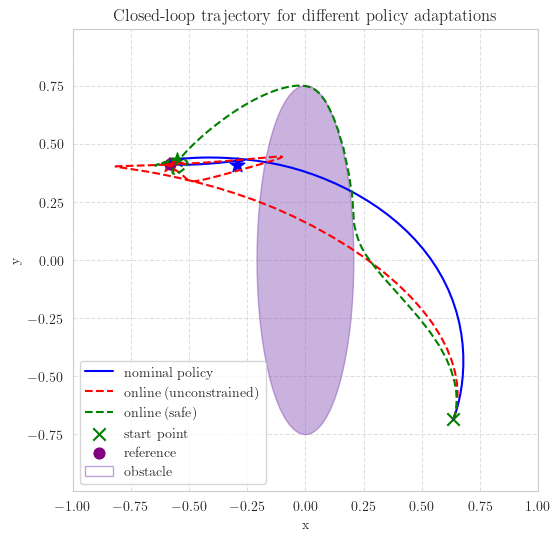

In [137]:
fig, ax = plot_trajectories_with_ellipse(
    traj_list=[
        {"traj": traj_x_noisy, "label": "nominal policy", "color": "blue"},
        {"traj": x_trajectory_unconst,   "label": "online (unconstrained)",   "color": "red", "linestyle": "--"},
        {"traj": x_trajectory_const,   "label": "online (safe)",   "color": "green", "linestyle": "--"}
    ],
    r = traj_r,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    batch_idx=0, xmin=xmin, xmax=xmax,
    title="Closed-loop trajectory for different policy adaptations"
)


In [138]:
noisy_policy_sparse.pretty_print()

u0 = -1.1333e-01·x0 + +5.0556e-01·r1 + +6.1309e-01·sqrt(x0) + +5.3565e-02·sqrt(x3) + -2.3363e-01·x0*r1 + -1.8524e+00·x1*r1 + +1.4511e+00·x2*r0 + +6.9460e-01·x3*r0
u1 = +4.4336e-01·x1 + -6.3737e-01·x2 + -1.2555e+00·x3 + +6.0672e-01·r1 + +2.2078e-01·sqrt(x0)


In [139]:
policy_sparse.pretty_print()

u0 = -5.4323e-01·x0 + +1.8101e-01·r1 + +3.5956e-01·sqrt(x0) + -2.2505e-01·sqrt(x3) + -6.6320e-01·x0*r1 + -1.4094e+00·x1*r1 + +1.3210e+00·x2*r0 + +1.1133e+00·x3*r0
u1 = +1.5959e-01·x1 + -6.5742e-01·x2 + -1.0599e+00·x3 + +6.5525e-01·r1 + +1.7086e-01·sqrt(x0)


In [140]:
# Closed-loop simulation setup


data = make_test_sample(
    nx=nx, nsteps=nsteps, seed= 21
    , device=device,
    ellipse= ellipse_configs,
    init_vel_std=0.0,
    init_rect= init_rect,
    ref_rect= ref_rect,
)


gt_integrator = integrators.Euler(double_integrator, h=torch.tensor(ts))
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

gt_integrator_noisy = integrators.Euler(double_integrator_noisy, h=torch.tensor(ts))
gt_integrator_node_noisy = Node(gt_integrator_noisy, ['xn', 'u'], ['xn'], name='model')

policy_node = Node(
            lambda xn,r : torch.clamp(policy_sparse(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )

noisy_policy_node = Node(
            lambda xn,r : torch.clamp(noisy_policy_sparse(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="noisy_policy_combined"
        )
# Compose symbolic closed-loop system: policy + true plant
gt_sindy_policy_system = copy.deepcopy(System([policy_node, gt_integrator_node]))
gt_sindy_policy_system_noisy = copy.deepcopy(System([noisy_policy_node, gt_integrator_node_noisy]))

# Simulate system
gt_sindy_policy_system.nsteps = nsteps
gt_sindy_policy_system_noisy.nsteps = nsteps

trajectories = gt_sindy_policy_system(data)
trajectories_noisy = gt_sindy_policy_system_noisy(data)

traj_x = trajectories["xn"]
traj_r = trajectories['r']

traj_x_noisy = trajectories_noisy["xn"]
traj_r_noisy = trajectories_noisy['r']

# suppose you produced a rollout: traj_x: (B, T, nx), traj_r: (B, T, 2)
fig, ax = plot_trajectories_with_ellipse(
    traj_list=[
        {"traj": traj_x, "label": "nominal system", "color": "blue"},
        {"traj": traj_x_noisy,   "label": "noisy system",   "color": "red", "linestyle": "--"}
    ],
    r = traj_r,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    batch_idx=0, xmin=xmin, xmax=xmax,
    title="Closed-loop trajectory"
)


NameError: name 'double_integrator_noisy' is not defined